### UAS BENGKEL KODING - DATA SCIENCE
#### Prediksi Customer Churn dengan Machine Learning
Identitas:
- Nama  : ANGELICA WIDYASTUTI KOLO
- NIM   : A11.2021.13212
- Kelas : BENGKOD - DS01
- Dataset: Telco Customer Churn

### 1. IMPORT LIBRARY

In [ ]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Metrik Evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Library untuk simpan model
import pickle
import joblib

# Konfigurasi tampilan
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✅ Library berhasil diimport!\n")

✅ Library berhasil diimport!



### 2. LOAD DATASET

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
print(f"✅ Dataset berhasil dimuat!")
print(f"📊 Jumlah Baris: {df.shape[0]}")
print(f"📊 Jumlah Kolom: {df.shape[1]}\n")

✅ Dataset berhasil dimuat!
📊 Jumlah Baris: 7043
📊 Jumlah Kolom: 21



### BAGIAN I: EXPLORATORY DATA ANALYSIS (EDA)

#### 1. Eksplorasi Awal

In [ ]:
print("\n🔹 5 Baris Pertama Dataset:")
display(df.head())

print("\n🔹 Informasi Dataset:")
df.info()

print("\n🔹 Statistik Deskriptif:")
display(df.describe())

# CRITICAL FIX: Kolom TotalCharges terbaca sebagai object
print("\n⚠️ PERBAIKAN DATA: Mengubah TotalCharges menjadi numerik...")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
print("✅ TotalCharges berhasil diubah menjadi numerik\n")


🔹 5 Baris Pertama Dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



🔹 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



⚠️ PERBAIKAN DATA: Mengubah TotalCharges menjadi numerik...
✅ TotalCharges berhasil diubah menjadi numerik



#### 2. Identifikasi Missing Value


🔹 Persentase Missing Value per Kolom:
✅ Tidak ada missing value dalam dataset


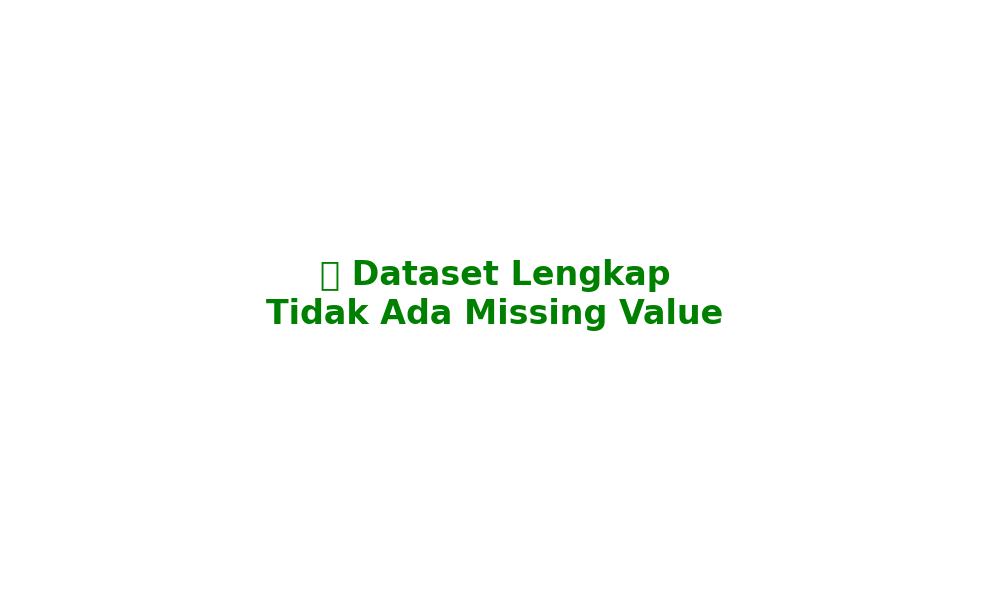


✅ Identifikasi missing value selesai



In [ ]:
# Hitung persentase missing value
missing_data = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Kolom': missing_data.index,
    'Persentase Missing (%)': missing_data.values
})

print("\n🔹 Persentase Missing Value per Kolom:")

# Filter hanya kolom yang punya missing value
missing_df_filtered = missing_df[missing_df['Persentase Missing (%)'] > 0]

if len(missing_df_filtered) > 0:
    display(missing_df_filtered)

    # Visualisasi Missing Value (hanya jika ada missing value)
    plt.figure(figsize=(12, 6))
    missing_data[missing_data > 0].sort_values(ascending=False).plot(kind='bar', color='salmon')
    plt.title('Persentase Missing Value per Kolom', fontsize=16, fontweight='bold')
    plt.xlabel('Kolom', fontsize=12)
    plt.ylabel('Persentase (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\n⚠️ Ditemukan {len(missing_df_filtered)} kolom dengan missing value")
else:
    print("✅ Tidak ada missing value dalam dataset")

    # Visualisasi alternatif: tampilkan bahwa semua kolom lengkap
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.text(0.5, 0.5, '✅ Dataset Lengkap\nTidak Ada Missing Value',
            horizontalalignment='center', verticalalignment='center',
            fontsize=24, fontweight='bold', color='green',
            transform=ax.transAxes)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\n✅ Identifikasi missing value selesai\n")

#### 3. Visualisasi Distribusi Target (Churn)


🔹 Distribusi Target:
No (Tidak Churn): 5174 (73.46%)
Yes (Churn): 1869 (26.54%)


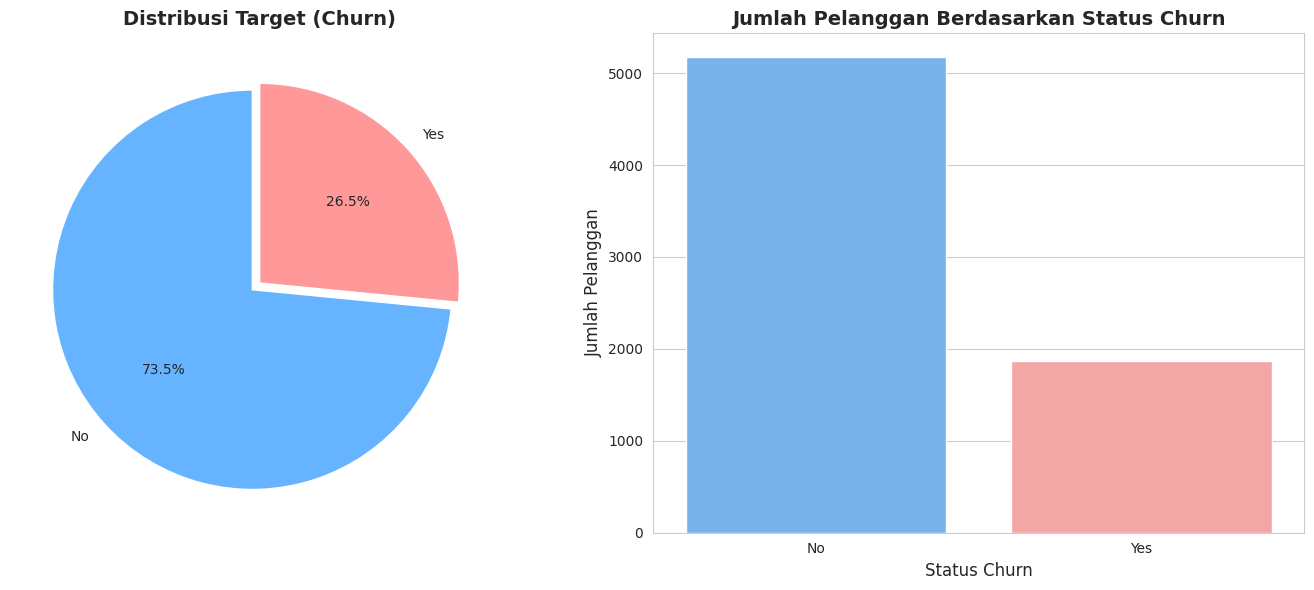


⚠️ Dataset IMBALANCED: Kelas 'No' dominan (73.5%)



In [ ]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("\n🔹 Distribusi Target:")
print(f"No (Tidak Churn): {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"Yes (Churn): {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Distribusi Target (Churn)', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='Churn', palette=['#66b3ff', '#ff9999'], ax=axes[1])
axes[1].set_title('Jumlah Pelanggan Berdasarkan Status Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Status Churn', fontsize=12)
axes[1].set_ylabel('Jumlah Pelanggan', fontsize=12)

plt.tight_layout()
plt.show()

print("\n⚠️ Dataset IMBALANCED: Kelas 'No' dominan (73.5%)\n")

#### 4. Analisis Korelasi Fitur Numerik

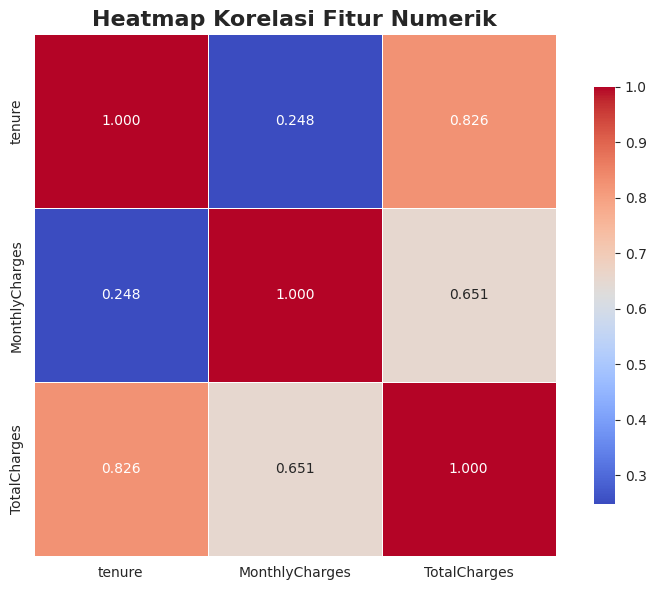


🔹 Insight Korelasi:
• tenure vs TotalCharges: 0.826 (Sangat Kuat)
• MonthlyCharges vs TotalCharges: 0.651 (Kuat)

✅ BAGIAN I (EDA) SELESAI!



In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔹 Insight Korelasi:")
print(f"• tenure vs TotalCharges: {correlation_matrix.loc['tenure', 'TotalCharges']:.3f} (Sangat Kuat)")
print(f"• MonthlyCharges vs TotalCharges: {correlation_matrix.loc['MonthlyCharges', 'TotalCharges']:.3f} (Kuat)")

print("\n✅ BAGIAN I (EDA) SELESAI!\n")

### BAGIAN II: DIRECT MODELING (SKENARIO 1)

#### Persiapan Data

In [ ]:
df_direct = df.copy()

# Encoding sederhana
le = LabelEncoder()
for column in df_direct.columns:
    if df_direct[column].dtype == 'object':
        df_direct[column] = le.fit_transform(df_direct[column])

print("✅ Encoding selesai\n")

# Pisahkan fitur dan target
X_direct = df_direct.drop('Churn', axis=1)
y_direct = df_direct['Churn']

# Train-Test Split
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

print(f"📊 Data Train: {X_train_dir.shape[0]} sampel")
print(f"📊 Data Test: {X_test_dir.shape[0]} sampel\n")

✅ Encoding selesai

📊 Data Train: 5634 sampel
📊 Data Test: 1409 sampel



#### Definisi Model

In [ ]:
# Model 1: Konvensional
model_lr_direct = LogisticRegression(max_iter=1000, random_state=42)

# Model 2: Ensemble Bagging
model_rf_direct = RandomForestClassifier(random_state=42, n_estimators=100)

# Model 3: Ensemble Voting
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=5)
clf3 = SVC(probability=True, random_state=42)
model_voting_direct = VotingClassifier(
    estimators=[('lr', clf1), ('knn', clf2), ('svm', clf3)],
    voting='soft'
)

models_direct = {
    'Logistic Regression': model_lr_direct,
    'Random Forest': model_rf_direct,
    'Voting Classifier': model_voting_direct
}

print("✅ 3 Model berhasil didefinisikan\n")

✅ 3 Model berhasil didefinisikan



#### Training & Evaluasi

In [ ]:
results_direct = []

for name, model in models_direct.items():
    print(f"\n🔹 Training Model: {name}")

    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    acc = accuracy_score(y_test_dir, y_pred)
    prec = precision_score(y_test_dir, y_pred)
    rec = recall_score(y_test_dir, y_pred)
    f1 = f1_score(y_test_dir, y_pred)

    results_direct.append([name, acc, prec, rec, f1])

    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test_dir, y_pred))
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 80)

# Tabel Hasil
print("\n📊 TABEL PERBANDINGAN - DIRECT MODELING")
df_results_direct = pd.DataFrame(results_direct,
                                  columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
display(df_results_direct)

print("\n✅ BAGIAN II (DIRECT MODELING) SELESAI!\n")


🔹 Training Model: Logistic Regression

Confusion Matrix:
[[917 118]
 [168 206]]

Accuracy : 0.7970
Precision: 0.6358
Recall   : 0.5508
F1-Score : 0.5903
--------------------------------------------------------------------------------

🔹 Training Model: Random Forest

Confusion Matrix:
[[929 106]
 [187 187]]

Accuracy : 0.7921
Precision: 0.6382
Recall   : 0.5000
F1-Score : 0.5607
--------------------------------------------------------------------------------

🔹 Training Model: Voting Classifier

Confusion Matrix:
[[960  75]
 [235 139]]

Accuracy : 0.7800
Precision: 0.6495
Recall   : 0.3717
F1-Score : 0.4728
--------------------------------------------------------------------------------

📊 TABEL PERBANDINGAN - DIRECT MODELING


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.797019,0.635802,0.550802,0.590258
1,Random Forest,0.792051,0.638225,0.500000,0.560720
2,Voting Classifier,0.779986,0.649533,0.371658,0.472789



✅ BAGIAN II (DIRECT MODELING) SELESAI!



### BAGIAN III: MODELING DENGAN PREPROCESSING (SKENARIO 2)

#### Preprocessing Data

In [ ]:
df_clean = df.copy()

# 1. Drop kolom tidak relevan
print("\n🔹 1. Drop kolom customerID")
df_clean.drop('customerID', axis=1, inplace=True)
print("✅ customerID dihapus\n")

# 2. Cek duplikasi
print("🔹 2. Cek duplikasi")
duplicates = df_clean.duplicated().sum()
print(f"   Jumlah duplikasi: {duplicates}")
if duplicates > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"   ✅ {duplicates} baris duplikat dihapus\n")
else:
    print("   ✅ Tidak ada duplikasi\n")

# 3. Handling Outlier dengan IQR
print("🔹 3. Handling Outlier dengan IQR Method")
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

def remove_outliers_iqr(df, columns):
    df_no_outliers = df.copy()
    for col in columns:
        Q1 = df_no_outliers[col].quantile(0.25)
        Q3 = df_no_outliers[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        before = len(df_no_outliers)
        df_no_outliers = df_no_outliers[
            (df_no_outliers[col] >= lower_bound) &
            (df_no_outliers[col] <= upper_bound)
        ]
        after = len(df_no_outliers)
        print(f"   • {col}: {before - after} outlier dihapus")

    return df_no_outliers

df_clean = remove_outliers_iqr(df_clean, numeric_features)
print(f"✅ Data tersisa: {len(df_clean)} baris\n")

# 4. Definisi kolom
print("🔹 4. Definisi Kolom")
target = 'Churn'
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in df_clean.columns if col not in num_cols and col != target]
print(f"   • Kolom Numerik: {len(num_cols)}")
print(f"   • Kolom Kategorikal: {len(cat_cols)}\n")

# 5. Preprocessing Pipeline
print("🔹 5. Membuat Pipeline")

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

print("✅ Pipeline berhasil dibuat\n")


🔹 1. Drop kolom customerID
✅ customerID dihapus

🔹 2. Cek duplikasi
   Jumlah duplikasi: 22
   ✅ 22 baris duplikat dihapus

🔹 3. Handling Outlier dengan IQR Method
   • tenure: 0 outlier dihapus
   • MonthlyCharges: 0 outlier dihapus
   • TotalCharges: 0 outlier dihapus
✅ Data tersisa: 7021 baris

🔹 4. Definisi Kolom
   • Kolom Numerik: 3
   • Kolom Kategorikal: 16

🔹 5. Membuat Pipeline
✅ Pipeline berhasil dibuat



#### Persiapan Data untuk Modeling

In [ ]:
X = df_clean.drop(target, axis=1)
y = df_clean[target].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Data Train: {X_train.shape[0]} sampel")
print(f"📊 Data Test: {X_test.shape[0]} sampel\n")

📊 Data Train: 5616 sampel
📊 Data Test: 1405 sampel



#### Definisi Model dengan Pipeline

In [ ]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Voting Classifier dengan Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

class VotingPipeline(BaseEstimator, ClassifierMixin):
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.clf1 = LogisticRegression(max_iter=1000, random_state=42)
        self.clf2 = KNeighborsClassifier(n_neighbors=5)
        self.clf3 = SVC(probability=True, random_state=42)
        self.voting_clf = VotingClassifier(
            estimators=[('lr', self.clf1), ('knn', self.clf2), ('svm', self.clf3)],
            voting='soft'
        )

    def fit(self, X, y):
        X_transformed = self.preprocessor.fit_transform(X)
        self.voting_clf.fit(X_transformed, y)
        return self

    def predict(self, X):
        X_transformed = self.preprocessor.transform(X)
        return self.voting_clf.predict(X_transformed)

    def predict_proba(self, X):
        X_transformed = self.preprocessor.transform(X)
        return self.voting_clf.predict_proba(X_transformed)

pipeline_voting = VotingPipeline(preprocessor)

models_preproc = {
    'Logistic Regression': pipeline_lr,
    'Random Forest': pipeline_rf,
    'Voting Classifier': pipeline_voting
}

print("✅ 3 Model dengan pipeline berhasil didefinisikan\n")

✅ 3 Model dengan pipeline berhasil didefinisikan



#### Training & Evaluasi

In [ ]:
results_preproc = []

for name, model in models_preproc.items():
    print(f"\n🔹 Training Model: {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_preproc.append([name, acc, prec, rec, f1])

    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 80)

# Tabel Hasil
print("\n📊 TABEL PERBANDINGAN - PREPROCESSING MODELING")
df_results_preproc = pd.DataFrame(results_preproc,
                                   columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
display(df_results_preproc)

print("\n✅ BAGIAN III (PREPROCESSING MODELING) SELESAI!\n")


🔹 Training Model: Logistic Regression

Confusion Matrix:
[[934  99]
 [179 193]]

Accuracy : 0.8021
Precision: 0.6610
Recall   : 0.5188
F1-Score : 0.5813
--------------------------------------------------------------------------------

🔹 Training Model: Random Forest

Confusion Matrix:
[[920 113]
 [203 169]]

Accuracy : 0.7751
Precision: 0.5993
Recall   : 0.4543
F1-Score : 0.5168
--------------------------------------------------------------------------------

🔹 Training Model: Voting Classifier

Confusion Matrix:
[[928 105]
 [196 176]]

Accuracy : 0.7858
Precision: 0.6263
Recall   : 0.4731
F1-Score : 0.5391
--------------------------------------------------------------------------------

📊 TABEL PERBANDINGAN - PREPROCESSING MODELING


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.802135,0.660959,0.518817,0.581325
1,Random Forest,0.775089,0.599291,0.454301,0.516820
2,Voting Classifier,0.785765,0.626335,0.473118,0.539051



✅ BAGIAN III (PREPROCESSING MODELING) SELESAI!



### BAGIAN III LANJUTAN: HYPERPARAMETER TUNING (SKENARIO 3)

#### 1. Tuning Logistic Regression

In [ ]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='f1',
                       n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_lr.best_params_}")
print(f"✅ Best CV Score: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\n📊 EVALUASI MODEL TUNED:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("-" * 80)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
✅ Best CV Score: 0.6013

📊 EVALUASI MODEL TUNED:
Accuracy : 0.8014
Precision: 0.6566
Recall   : 0.5242
F1-Score : 0.5830

Confusion Matrix:
[[931 102]
 [177 195]]
--------------------------------------------------------------------------------


#### 2. Tuning Random Forest

In [ ]:
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='f1',
                       n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_rf.best_params_}")
print(f"✅ Best CV Score: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\n📊 EVALUASI MODEL TUNED:")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("-" * 80)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
✅ Best CV Score: 0.5777

📊 EVALUASI MODEL TUNED:
Accuracy : 0.7964
Precision: 0.6493
Recall   : 0.5027
F1-Score : 0.5667

Confusion Matrix:
[[932 101]
 [185 187]]
--------------------------------------------------------------------------------


#### 3. Tuning Voting Classifier

In [ ]:
# Manual tuning untuk Voting (test beberapa kombinasi)
best_voting_score = 0
best_voting_model = None

for n_neighbors in [3, 5, 7]:
    temp_voting = VotingPipeline(preprocessor)
    temp_voting.clf2 = KNeighborsClassifier(n_neighbors=n_neighbors)
    temp_voting.voting_clf = VotingClassifier(
        estimators=[('lr', temp_voting.clf1), ('knn', temp_voting.clf2), ('svm', temp_voting.clf3)],
        voting='soft'
    )

    temp_voting.fit(X_train, y_train)
    y_pred_temp = temp_voting.predict(X_test)
    score = f1_score(y_test, y_pred_temp)

    print(f"   Testing n_neighbors={n_neighbors}: F1-Score = {score:.4f}")

    if score > best_voting_score:
        best_voting_score = score
        best_voting_model = temp_voting

print(f"\n✅ Best F1-Score: {best_voting_score:.4f}")

y_pred_voting = best_voting_model.predict(X_test)

acc_voting = accuracy_score(y_test, y_pred_voting)
prec_voting = precision_score(y_test, y_pred_voting)
rec_voting = recall_score(y_test, y_pred_voting)
f1_voting = f1_score(y_test, y_pred_voting)

print(f"\n📊 EVALUASI MODEL TUNED:")
print(f"Accuracy : {acc_voting:.4f}")
print(f"Precision: {prec_voting:.4f}")
print(f"Recall   : {rec_voting:.4f}")
print(f"F1-Score : {f1_voting:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))
print("-" * 80)

   Testing n_neighbors=3: F1-Score = 0.5477
   Testing n_neighbors=5: F1-Score = 0.5391
   Testing n_neighbors=7: F1-Score = 0.5474

✅ Best F1-Score: 0.5477

📊 EVALUASI MODEL TUNED:
Accuracy : 0.7907
Precision: 0.6403
Recall   : 0.4785
F1-Score : 0.5477

Confusion Matrix:
[[933 100]
 [194 178]]
--------------------------------------------------------------------------------


#### Tabel Perbandingan 9 Model

,Skenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct,Logistic Regression,0.797019,0.635802,0.550802,0.590258
1,Direct,Random Forest,0.792051,0.638225,0.500000,0.560720
2,Direct,Voting Classifier,0.779986,0.649533,0.371658,0.472789
3,Preprocessing,Logistic Regression,0.802135,0.660959,0.518817,0.581325
4,Preprocessing,Random Forest,0.775089,0.599291,0.454301,0.516820
5,Preprocessing,Voting Classifier,0.785765,0.626335,0.473118,0.539051
6,Tuning,Logistic Regression,0.801423,0.656566,0.524194,0.582960
7,Tuning,Random Forest,0.796441,0.649306,0.502688,0.566667
8,Tuning,Voting Classifier,0.790747,0.640288,0.478495,0.547692


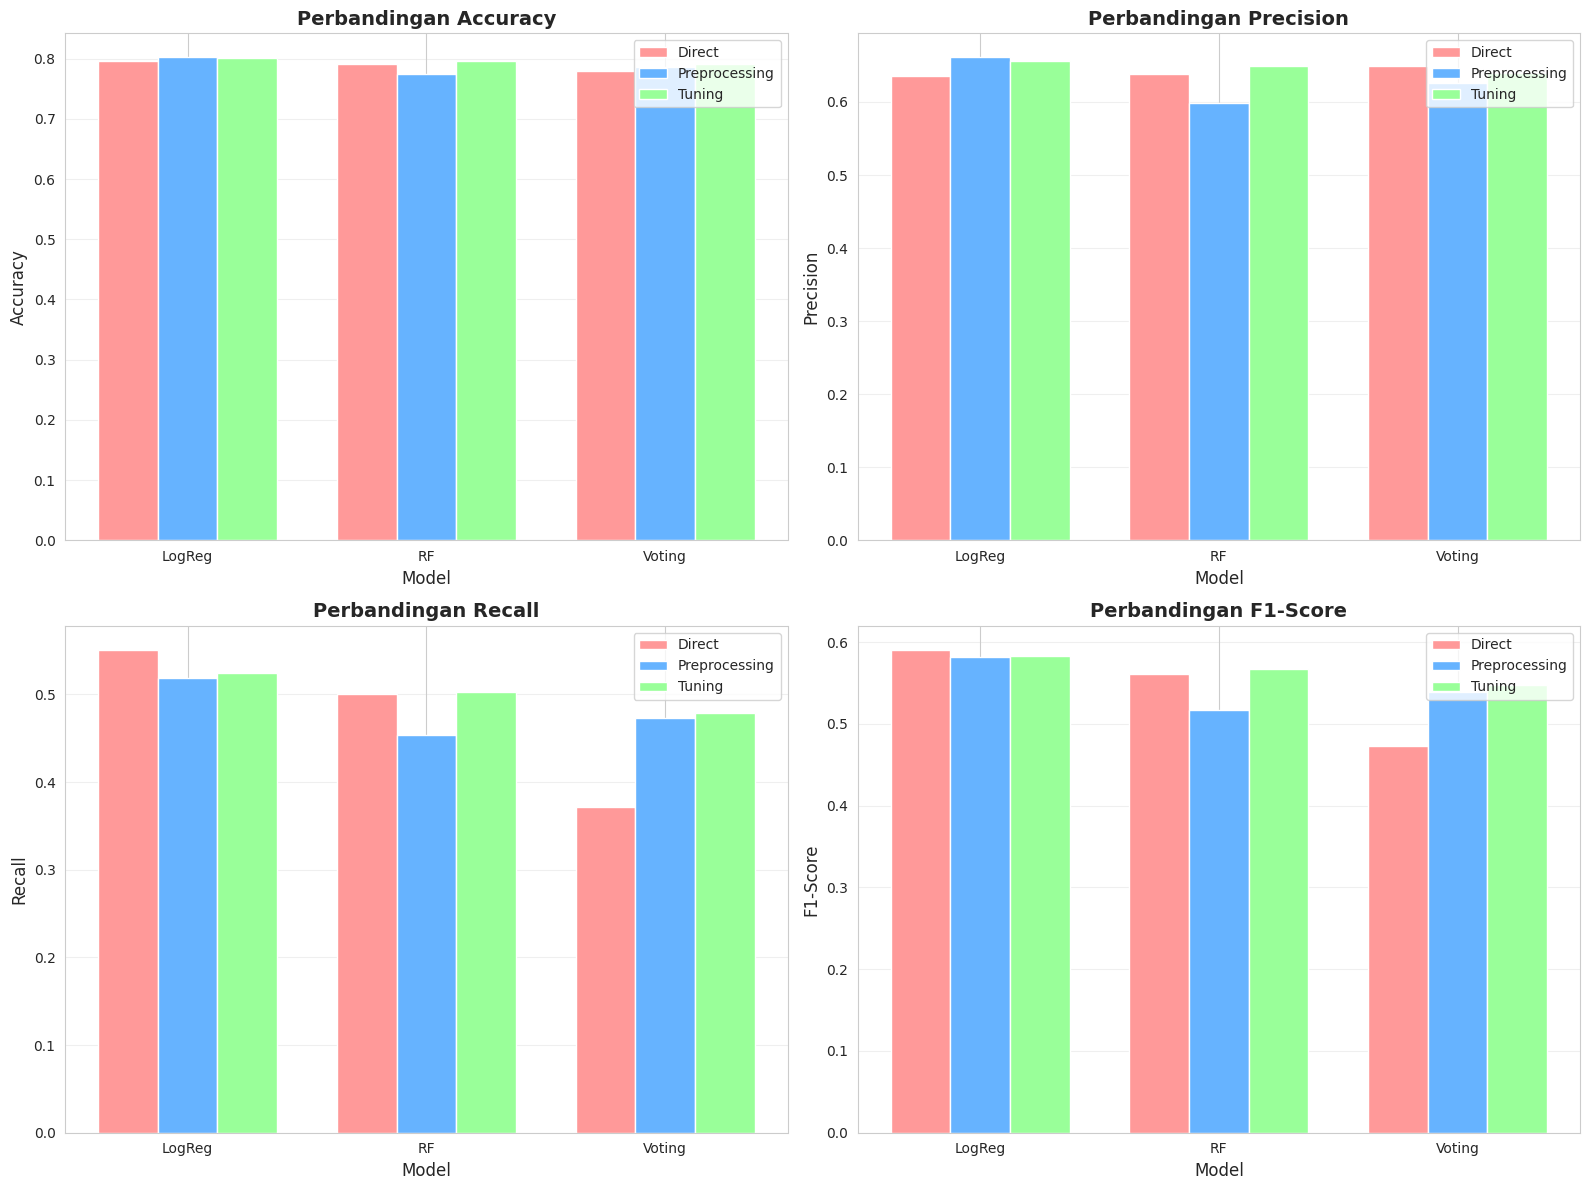

In [ ]:
results_tuned = [
    ['Logistic Regression', acc_lr, prec_lr, rec_lr, f1_lr],
    ['Random Forest', acc_rf, prec_rf, rec_rf, f1_rf],
    ['Voting Classifier', acc_voting, prec_voting, rec_voting, f1_voting]
]

df_all_results = pd.DataFrame(
    results_direct + results_preproc + results_tuned,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

df_all_results['Skenario'] = ['Direct']*3 + ['Preprocessing']*3 + ['Tuning']*3
df_all_results = df_all_results[['Skenario', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]

display(df_all_results)

# Visualisasi Perbandingan
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    direct_vals = df_all_results[df_all_results['Skenario'] == 'Direct'][metric].values
    preproc_vals = df_all_results[df_all_results['Skenario'] == 'Preprocessing'][metric].values
    tuning_vals = df_all_results[df_all_results['Skenario'] == 'Tuning'][metric].values

    x = np.arange(3)
    width = 0.25

    ax.bar(x - width, direct_vals, width, label='Direct', color='#ff9999')
    ax.bar(x, preproc_vals, width, label='Preprocessing', color='#66b3ff')
    ax.bar(x + width, tuning_vals, width, label='Tuning', color='#99ff99')

    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Perbandingan {metric}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['LogReg', 'RF', 'Voting'], rotation=0)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Identifikasi Model Terbaik

In [ ]:
best_idx = df_all_results['F1-Score'].idxmax()
best_model_info = df_all_results.iloc[best_idx]

print(f"\n🏆 MODEL TERBAIK:")
print(f"   Skenario : {best_model_info['Skenario']}")
print(f"   Model    : {best_model_info['Model']}")
print(f"   Accuracy : {best_model_info['Accuracy']:.4f}")
print(f"   Precision: {best_model_info['Precision']:.4f}")
print(f"   Recall   : {best_model_info['Recall']:.4f}")
print(f"   F1-Score : {best_model_info['F1-Score']:.4f}")

# Tentukan model untuk disimpan
if 'Logistic Regression' in best_model_info['Model']:
    final_best_model = best_lr
    model_name = 'Logistic Regression'
elif 'Random Forest' in best_model_info['Model']:
    final_best_model = best_rf
    model_name = 'Random Forest'
else:
    final_best_model = best_voting_model
    model_name = 'Voting Classifier'

print(f"\n✅ Model yang akan disimpan: {model_name}\n")


🏆 MODEL TERBAIK:
   Skenario : Direct
   Model    : Logistic Regression
   Accuracy : 0.7970
   Precision: 0.6358
   Recall   : 0.5508
   F1-Score : 0.5903

✅ Model yang akan disimpan: Logistic Regression



#### SIMPAN MODEL TERBAIK

In [ ]:
# ============================================================================
# SIMPAN MODEL DENGAN BENAR (PYTHON 3.12 + SKLEARN 1.6.1)
# ============================================================================
print("\n" + "=" * 80)
print("💾 MENYIMPAN MODEL TERBAIK")
print("=" * 80)

import pickle
import joblib
import os

filename = 'model_churn_terbaik.pkl'

try:
    # Save dengan protocol 5 (untuk Python 3.8+)
    with open(filename, 'wb') as f:
        pickle.dump(final_best_model, f, protocol=5)

    print(f"✅ Model berhasil disimpan: {filename}")

    # Validasi: Test load model
    print("\n🔍 Validasi model...")
    with open(filename, 'rb') as f:
        test_model = pickle.load(f)

    print("✅ Test load: BERHASIL")

    # Test prediksi dengan 1 sample data
    test_sample = X_test.iloc[0:1]
    test_pred = test_model.predict(test_sample)
    test_proba = test_model.predict_proba(test_sample)

    print(f"✅ Test prediksi: {test_pred[0]}")
    print(f"✅ Test probabilitas: {test_proba[0]}")

    # Info file
    file_size = os.path.getsize(filename) / (1024 * 1024)
    print(f"\n📊 Ukuran file: {file_size:.2f} MB")

    # Simpan info tambahan untuk debugging
    model_metadata = {
        'model_type': str(type(final_best_model)),
        'sklearn_version': sklearn.__version__,
        'pandas_version': pd.__version__,
        'numpy_version': np.__version__,
        'python_version': sys.version.split()[0],
        'feature_names': list(X_test.columns),
        'n_features': len(X_test.columns)
    }

    with open('model_metadata.pkl', 'wb') as f:
        pickle.dump(model_metadata, f, protocol=5)

    print("✅ Metadata disimpan: model_metadata.pkl")

    print("\n" + "=" * 80)
    print("🎉 PROSES PENYIMPANAN SELESAI!")
    print("=" * 80)
    print("\n📥 DOWNLOAD FILE BERIKUT:")
    print("   1. ✅ model_churn_terbaik.pkl    ← FILE UTAMA (WAJIB)")
    print("   2. 📋 model_metadata.pkl         ← Info debugging (opsional)")
    print("\n🚀 LANGKAH SELANJUTNYA:")
    print("   1. Download file model_churn_terbaik.pkl")
    print("   2. Letakkan di folder yang sama dengan app.py")
    print("   3. Pastikan requirements.txt sudah update")
    print("   4. Test lokal: streamlit run app.py")
    print("   5. Upload ke GitHub & Deploy")
    print("=" * 80)

    # Download otomatis (khusus Google Colab)
    try:
        from google.colab import files
        print("\n📦 Mengunduh file model...")
        files.download(filename)
        print("✅ Download selesai!")
    except:
        print("\n⚠️ Untuk download manual:")
        print("   Klik kanan pada file → Download")

except Exception as e:
    print(f"\n❌ ERROR saat menyimpan model:")
    print(f"   Error Type: {type(e).__name__}")
    print(f"   Error Message: {str(e)}")
    import traceback
    traceback.print_exc()


💾 MENYIMPAN MODEL TERBAIK
✅ Model berhasil disimpan: model_churn_terbaik.pkl

🔍 Validasi model...
✅ Test load: BERHASIL
✅ Test prediksi: 1
✅ Test probabilitas: [0.24032154 0.75967846]

📊 Ukuran file: 0.00 MB
✅ Metadata disimpan: model_metadata.pkl

🎉 PROSES PENYIMPANAN SELESAI!

📥 DOWNLOAD FILE BERIKUT:
   1. ✅ model_churn_terbaik.pkl    ← FILE UTAMA (WAJIB)
   2. 📋 model_metadata.pkl         ← Info debugging (opsional)

🚀 LANGKAH SELANJUTNYA:
   1. Download file model_churn_terbaik.pkl
   2. Letakkan di folder yang sama dengan app.py
   3. Pastikan requirements.txt sudah update
   4. Test lokal: streamlit run app.py
   5. Upload ke GitHub & Deploy

📦 Mengunduh file model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!
